Install & Import Libraries

In [1]:
!pip install nltk wordcloud

import pandas as pd
import numpy as np
import re
import nltk
import pickle

from nltk.corpus import stopwords
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Load Datasets

In [2]:
toxic = pd.read_csv("train.csv")
hate = pd.read_csv("labeled_data.csv")

print("Toxic Dataset:", toxic.shape)
print("Hate Dataset:", hate.shape)

Toxic Dataset: (159571, 8)
Hate Dataset: (24783, 7)


Standardize Labels

Toxic Dataset

In [3]:
toxic['label'] = toxic[
['toxic','severe_toxic','obscene','threat','insult','identity_hate']
].max(axis=1)

toxic = toxic[['comment_text','label']]

Hate Speech Dataset 0 = Hate Speech
1 = Offensive
2 = Normal

In [5]:
hate['label'] = hate['class'].apply(lambda x: 0 if x==2 else 1)
hate = hate.rename(columns={'tweet':'comment_text'})
hate = hate[['comment_text','label']]

Merge Datasets

In [6]:
data = pd.concat([toxic, hate], ignore_index=True)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total comments:", len(data))

Total comments: 184354


Text Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    return " ".join(words)

data['clean_text'] = data['comment_text'].apply(clean_text)

TF-IDF Feature Extraction

In [8]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['label']

Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Machine Learning Models

Naive Bayes

In [10]:
nb = MultinomialNB()
nb.fit(X_train,y_train)

nb_pred = nb.predict(X_test)

Logistic Regression

In [11]:
log_model = LogisticRegression(max_iter=300)
log_model.fit(X_train,y_train)

log_pred = log_model.predict(X_test)

Support Vector Machine

In [12]:
svm = LinearSVC()
svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

Evaluation Function

In [13]:
def evaluate_model(name, y_true, y_pred):

    acc = accuracy_score(y_true,y_pred)
    precision = precision_score(y_true,y_pred)
    recall = recall_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)

    print(f"\n{name} Performance")
    print("Accuracy:",acc)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1 Score:",f1)

    print(classification_report(y_true,y_pred))

    return acc

In [14]:
bayes_acc = evaluate_model("Naive Bayes",y_test,nb_pred)
log_acc = evaluate_model("Logistic Regression",y_test,log_pred)
svm_acc = evaluate_model("SVM",y_test,svm_pred)


Naive Bayes Performance
Accuracy: 0.9407393344362779
Precision: 0.8830555965196873
Recall: 0.8113821138211382
F1 Score: 0.8457029870771838
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     29491
           1       0.88      0.81      0.85      7380

    accuracy                           0.94     36871
   macro avg       0.92      0.89      0.90     36871
weighted avg       0.94      0.94      0.94     36871


Logistic Regression Performance
Accuracy: 0.9571207724227713
Precision: 0.9600190385530699
Recall: 0.8199186991869919
F1 Score: 0.8844551633413725
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     29491
           1       0.96      0.82      0.88      7380

    accuracy                           0.96     36871
   macro avg       0.96      0.91      0.93     36871
weighted avg       0.96      0.96      0.96     36871


SVM Performance
Accuracy: 0.9592091345501885
Precision: 0

Overfitting Check

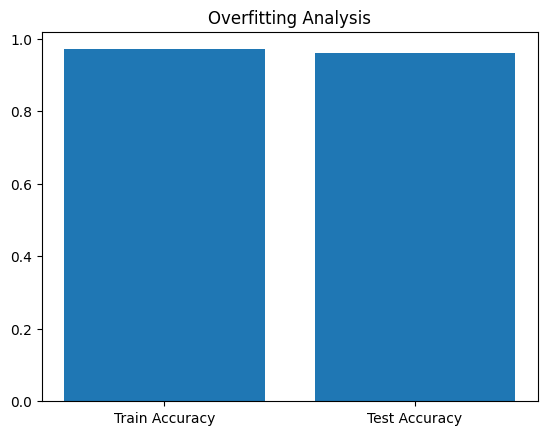

In [15]:
train_acc = svm.score(X_train,y_train)
test_acc = svm.score(X_test,y_test)

plt.bar(["Train Accuracy","Test Accuracy"],[train_acc,test_acc])
plt.title("Overfitting Analysis")
plt.show()

Confusion Matrix

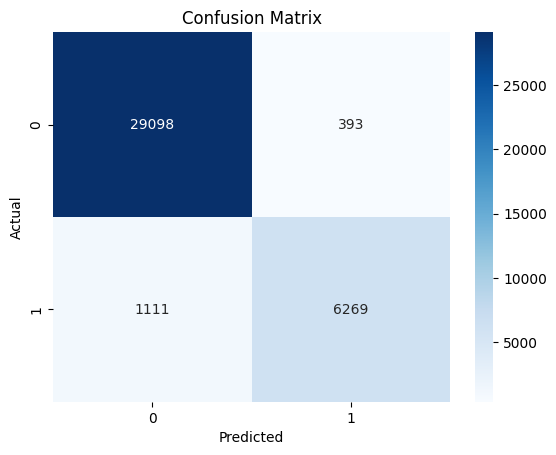

In [16]:
cm = confusion_matrix(y_test,svm_pred)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve

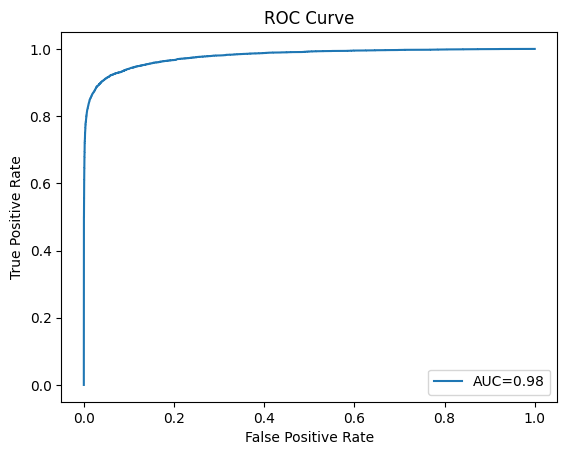

In [17]:
y_score = svm.decision_function(X_test)

fpr,tpr,_ = roc_curve(y_test,y_score)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Dataset Visualizations

Distribution

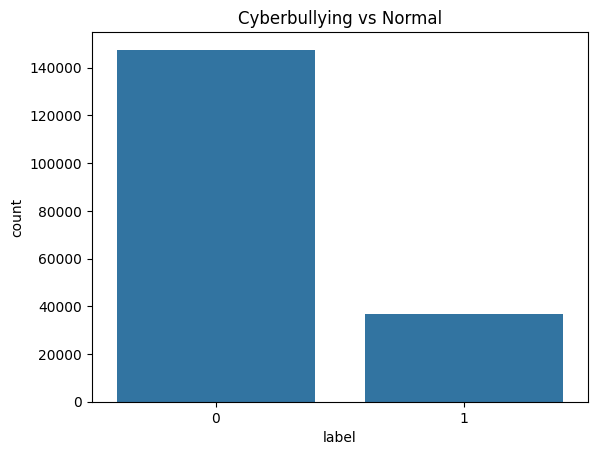

In [18]:
sns.countplot(x=data['label'])
plt.title("Cyberbullying vs Normal")
plt.show()

Frequent Words

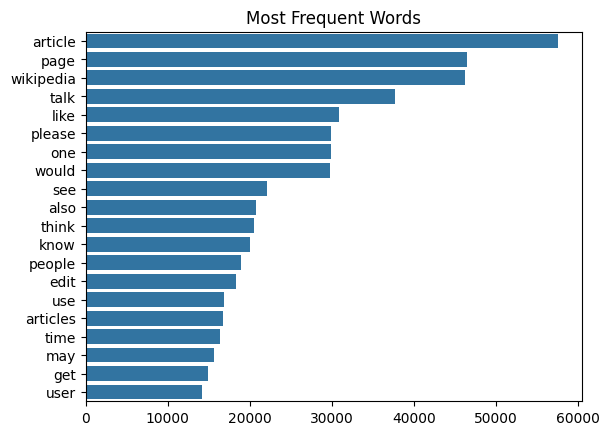

In [19]:
words = " ".join(data['clean_text']).split()
common_words = Counter(words).most_common(20)

w = [i[0] for i in common_words]
c = [i[1] for i in common_words]

sns.barplot(x=c,y=w)
plt.title("Most Frequent Words")
plt.show()

WordCloud

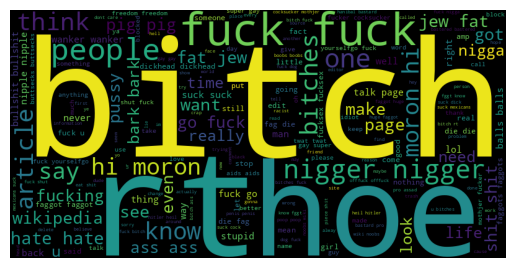

In [20]:
text = " ".join(data[data['label']==1]['clean_text'])

wordcloud = WordCloud(
width=800,
height=400,
background_color='black'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Hybrid Cyberbullying Detection (ML + Keyword)

In [21]:
bad_words = [
"kill yourself","suicide","die","ugly",
"loser","idiot","worthless","stupid",
"moron","hate you","bitch","fuck"
]

def keyword_check(text):
    text = text.lower()
    return any(word in text for word in bad_words)

Detection Function

In [22]:
def detect_comment(comment):

    print("User Comment:",comment)

    if keyword_check(comment):
        print("⚠ Harmful keyword detected")
        print("❌ Comment BLOCKED")
        return

    cleaned = clean_text(comment)
    vector = vectorizer.transform([cleaned])
    prediction = svm.predict(vector)

    if prediction[0]==1:
        print("🚫 Cyberbullying detected")
    else:
        print("✅ Safe Comment")

Test

In [23]:
detect_comment("you are ugly")
detect_comment("great video bro")

User Comment: you are ugly
⚠ Harmful keyword detected
❌ Comment BLOCKED
User Comment: great video bro
✅ Safe Comment


Save Model (FOR STREAMLIT)

In [24]:
pickle.dump(svm,open("cyberbullying_model.pkl","wb"))
pickle.dump(vectorizer,open("vectorizer.pkl","wb"))